# Renderer & Slicer — Visual Exploration
Demonstrates `render_name` and `slice_image` on `'Google'` vs `'G00gle'`.

In [1]:
import sys
sys.path.insert(0, '..')  # make rendering/ importable from notebooks/

import numpy as np
import matplotlib.pyplot as plt
from rendering.renderer import render_name
from rendering.slicer import slice_image

## 1. Rendered images

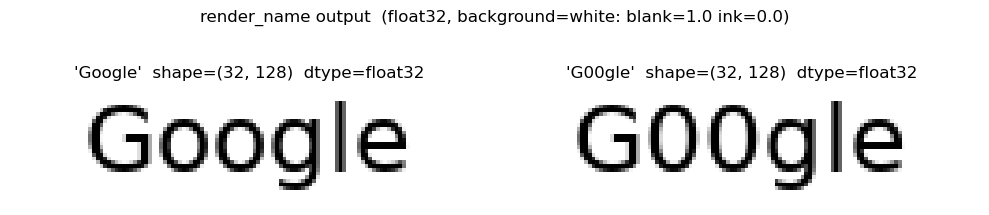

In [2]:
words = ['Google', 'G00gle']
imgs = {w: render_name(w) for w in words}

fig, axes = plt.subplots(1, 2, figsize=(10, 2))
for ax, w in zip(axes, words):
    ax.imshow(imgs[w], cmap='gray', vmin=0, vmax=1,
              aspect='auto', interpolation='nearest')
    ax.set_title(f'{w!r}  shape={imgs[w].shape}  dtype={imgs[w].dtype}')
    ax.axis('off')
plt.suptitle('render_name output  (float32, background=white: blank=1.0 ink=0.0)', y=1.05)
plt.tight_layout()
plt.show()


## 2. Slice heatmaps

Each slice is a `(height, slice_width)` column strip. Slices are shown side-by-side with a narrow separator; index labels are overlaid in the centre of each strip.

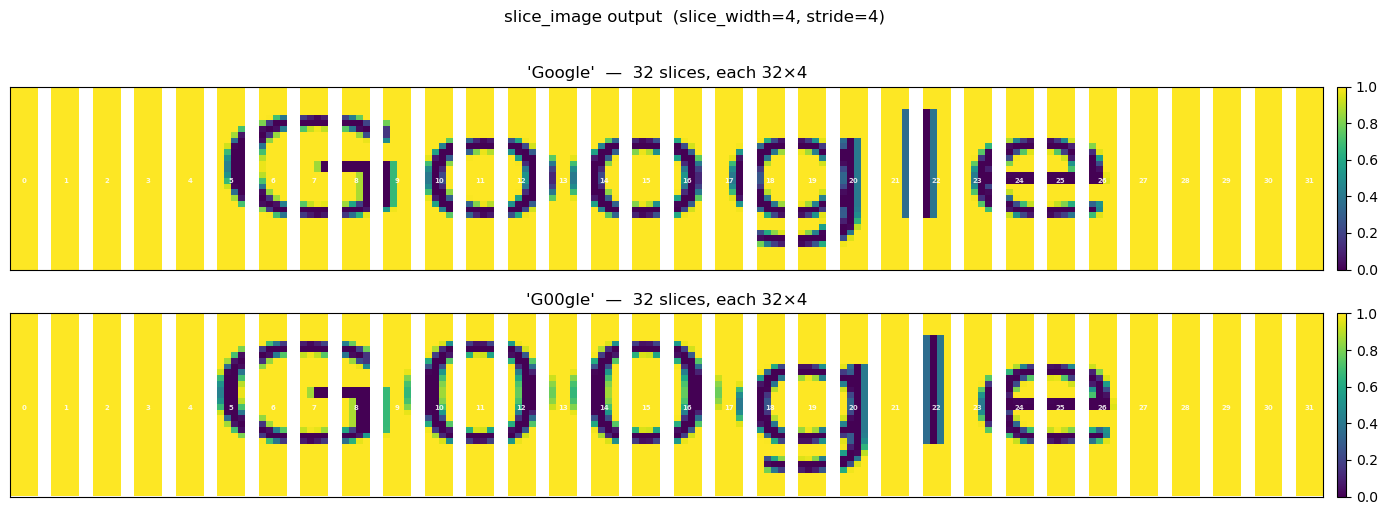

In [3]:
slices = {w: slice_image(imgs[w]) for w in words}

sep = 2  # separator columns between strips

fig, axes = plt.subplots(len(words), 1, figsize=(14, 2 * len(words) + 1), squeeze=False)
axes = axes[:, 0]

for ax, w in zip(axes, words):
    strips = slices[w]           # (n, h, sw)
    n, h, sw = strips.shape

    sep_col = np.full((h, sep), np.nan)
    mosaic = np.concatenate(
        [np.concatenate([strips[i], sep_col], axis=1) for i in range(n)], axis=1
    )[:, :-sep]

    im = ax.imshow(mosaic, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    for i in range(n):
        cx = i * (sw + sep) + (sw - 1) / 2
        ax.text(cx, h / 2, str(i), ha='center', va='center',
                fontsize=5, color='white', fontweight='bold', alpha=0.85)

    ax.set_title(f'{w!r}  —  {n} slices, each {h}×{sw}')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.01, pad=0.01)

plt.suptitle('slice_image output  (slice_width=4, stride=4)', y=1.02)
plt.tight_layout()
plt.show()

## 3. Difference map

Absolute per-slice difference between `'Google'` and `'G00gle'` highlights where the glyphs diverge.

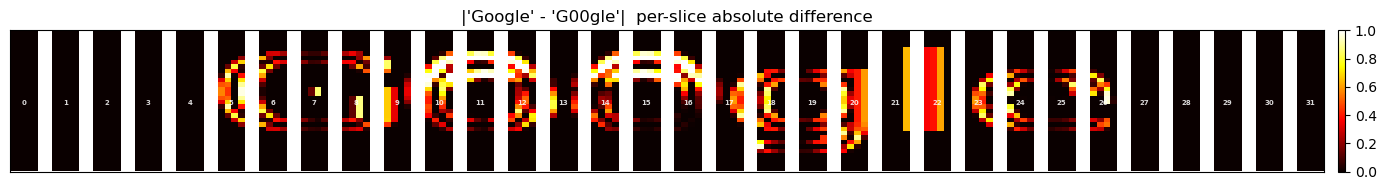

Mean absolute difference: 0.0821
Max  absolute difference: 1.0000


In [4]:
strips_diff = np.abs(slices['Google'] - slices['G00gle'])  # (n, h, sw)
n, h, sw = strips_diff.shape
sep = 2

sep_col = np.full((h, sep), np.nan)
mosaic = np.concatenate(
    [np.concatenate([strips_diff[i], sep_col], axis=1) for i in range(n)], axis=1
)[:, :-sep]

fig, ax = plt.subplots(figsize=(14, 2))
im = ax.imshow(mosaic, cmap='hot', aspect='auto', vmin=0, vmax=1)
for i in range(n):
    cx = i * (sw + sep) + (sw - 1) / 2
    ax.text(cx, h / 2, str(i), ha='center', va='center',
            fontsize=5, color='white', fontweight='bold', alpha=0.85)
ax.set_title("|'Google' - 'G00gle'|  per-slice absolute difference")
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(im, ax=ax, fraction=0.01, pad=0.01)
plt.tight_layout()
plt.show()

diff = strips_diff  # keep name for stats
print(f'Mean absolute difference: {diff.mean():.4f}')
print(f'Max  absolute difference: {diff.max():.4f}')

## 4. Varying height and slice parameters

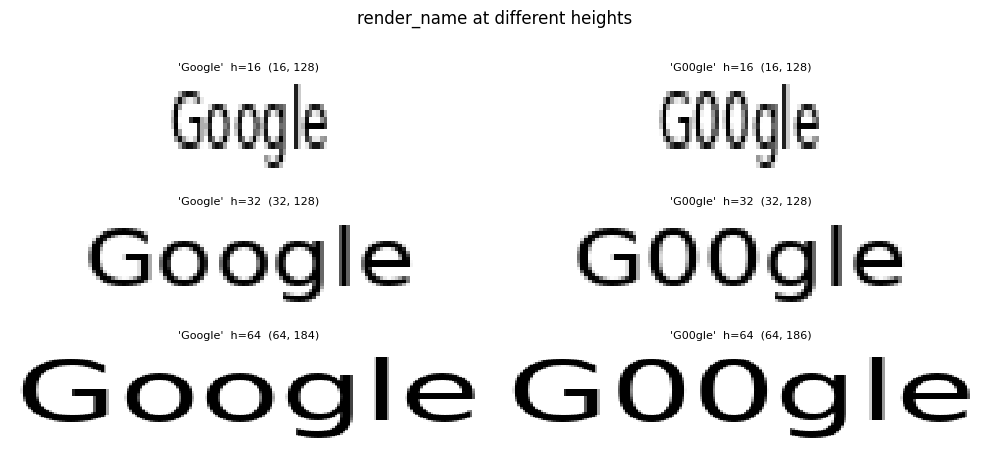

In [5]:
heights = [16, 32, 64]
fig, axes = plt.subplots(len(heights), 2, figsize=(10, len(heights) * 1.5))

for row, h in enumerate(heights):
    for col, w in enumerate(words):
        img = render_name(w, height=h)
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1,
                              aspect='auto', interpolation='nearest')
        axes[row, col].set_title(f'{w!r}  h={h}  {img.shape}', fontsize=8)
        axes[row, col].axis('off')

plt.suptitle('render_name at different heights', y=1.01)
plt.tight_layout()
plt.show()


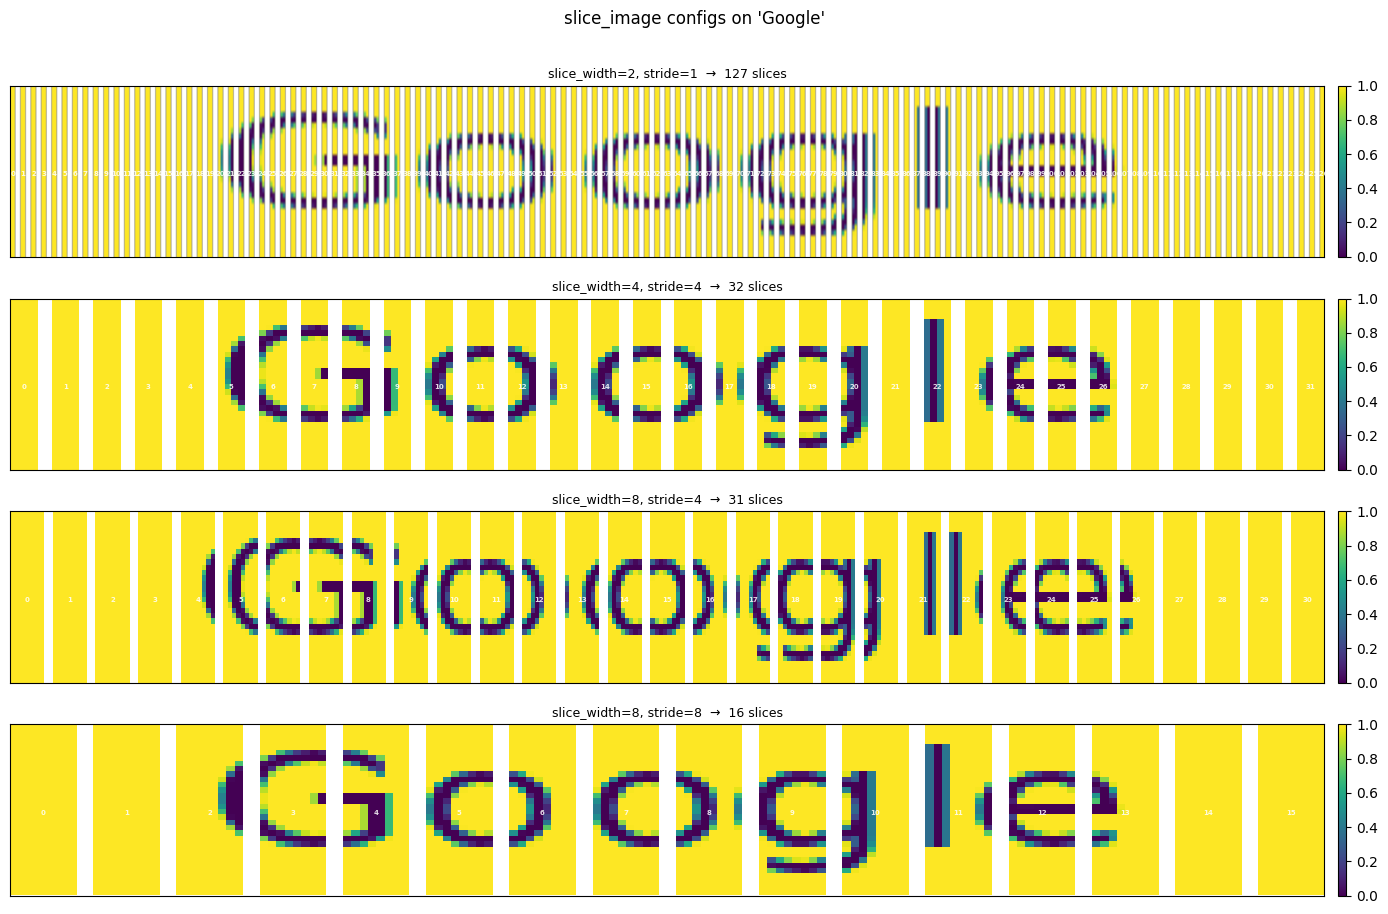

In [6]:
configs = [(2, 1), (4, 4), (8, 4), (8, 8)]
sep = 2
img_google = render_name('Google')

fig, axes = plt.subplots(len(configs), 1, figsize=(14, 2 * len(configs) + 1), squeeze=False)
axes = axes[:, 0]

for ax, (sw, st) in zip(axes, configs):
    strips = slice_image(img_google, slice_width=sw, stride=st)  # (n, h, sw)
    n, h, _ = strips.shape

    sep_col = np.full((h, sep), np.nan)
    mosaic = np.concatenate(
        [np.concatenate([strips[i], sep_col], axis=1) for i in range(n)], axis=1
    )[:, :-sep]

    im = ax.imshow(mosaic, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    for i in range(n):
        cx = i * (sw + sep) + (sw - 1) / 2
        ax.text(cx, h / 2, str(i), ha='center', va='center',
                fontsize=5, color='white', fontweight='bold', alpha=0.85)
    ax.set_title(f'slice_width={sw}, stride={st}  →  {n} slices', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.01, pad=0.01)

plt.suptitle("slice_image configs on 'Google'", y=1.01)
plt.tight_layout()
plt.show()


## 5. Background modes

`render_name` supports `background='white'` (default) and `background='black'`. In both cases blank space = 0.0 and ink = 1.0.

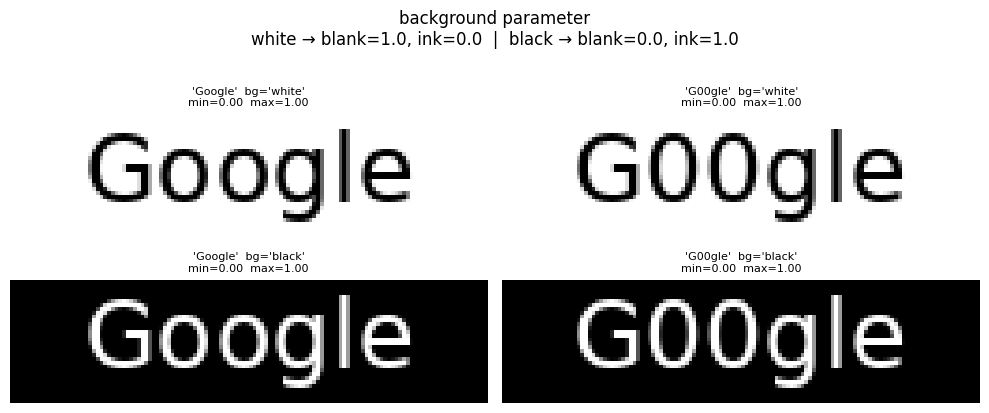

In [7]:
backgrounds = ['white', 'black']

fig, axes = plt.subplots(2, 2, figsize=(10, 4))
for col, w in enumerate(words):
    for row, bg in enumerate(backgrounds):
        img = render_name(w, background=bg)
        ax = axes[row, col]
        ax.imshow(img, cmap='gray', vmin=0, vmax=1,
                  aspect='auto', interpolation='nearest')
        ax.set_title(
            f'{w!r}  bg={bg!r}\nmin={img.min():.2f}  max={img.max():.2f}',
            fontsize=8,
        )
        ax.axis('off')

plt.suptitle(
    "background parameter\n"
    "white → blank=1.0, ink=0.0  |  black → blank=0.0, ink=1.0",
    y=1.02,
)
plt.tight_layout()
plt.show()


# Figures for Paper

### Strip preprocessing

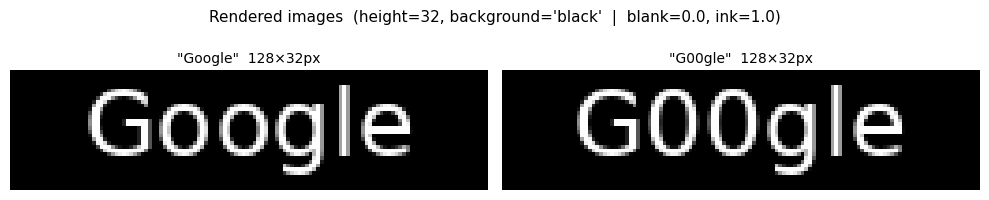

In [8]:
# ── Plot 1: Rendered images ────────────────────────────────────────────────
# Default config: height=32, background='black'
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
from rendering.renderer import render_name

HEIGHT     = 32
BACKGROUND = 'black'
WORDS      = ['Google', 'G00gle']

imgs = {w: render_name(w, height=HEIGHT, background=BACKGROUND) for w in WORDS}

render_fig, render_axes = plt.subplots(1, 2, figsize=(10, 2))
for ax, w in zip(render_axes, WORDS):
    ax.imshow(imgs[w], cmap='gray', vmin=0, vmax=1,
              aspect='auto', interpolation='nearest')
    ax.set_title(f'"{w}"  {imgs[w].shape[1]}×{imgs[w].shape[0]}px', fontsize=10)
    ax.axis('off')

render_fig.suptitle(
    f'Rendered images  (height={HEIGHT}, background={BACKGROUND!r}  |  blank=0.0, ink=1.0)',
    fontsize=11,
)
render_fig.tight_layout()
plt.show()

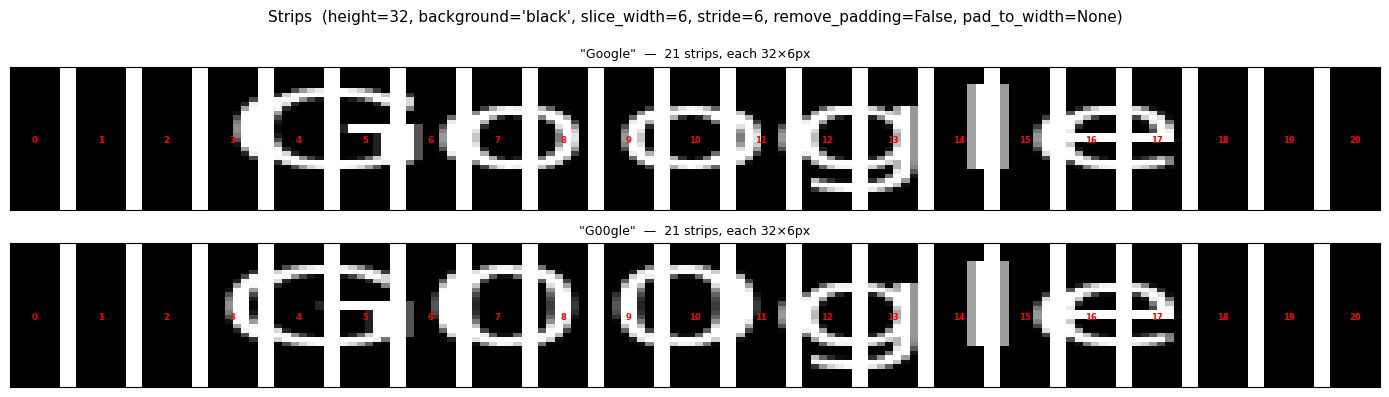

In [9]:
# ── Plot 2: Strips (slice heatmap) ────────────────────────────────────────
# Default config: slice_width=6, stride=6, remove_padding=false, pad_to_width=null
from rendering.slicer import slice_image

SLICE_WIDTH     = 6
STRIDE          = 6
REMOVE_PADDING  = False
PAD_TO_WIDTH    = None

slices = {w: slice_image(imgs[w], slice_width=SLICE_WIDTH, stride=STRIDE,
                          remove_padding=REMOVE_PADDING, pad_to_width=PAD_TO_WIDTH)
          for w in WORDS}

SEP = 2

strips_fig, strips_axes = plt.subplots(2, 1, figsize=(14, 4), squeeze=False)
strips_axes = strips_axes[:, 0]

for ax, w in zip(strips_axes, WORDS):
    s = slices[w]           # (n, h, sw)
    n, h, sw = s.shape
    sep_col = np.full((h, SEP), np.nan)
    mosaic = np.concatenate(
        [np.concatenate([s[i], sep_col], axis=1) for i in range(n)], axis=1
    )[:, :-SEP]

    ax.imshow(mosaic, cmap='gray', aspect='auto', vmin=0, vmax=1,
              interpolation='nearest')
    for i in range(n):
        cx = i * (sw + SEP) + (sw - 1) / 2
        ax.text(cx, h / 2, str(i), ha='center', va='center',
                fontsize=6, color='red', fontweight='bold')
    ax.set_title(f'"{w}"  —  {n} strips, each {h}×{sw}px', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

strips_fig.suptitle(
    f'Strips  (height={HEIGHT}, background={BACKGROUND!r}, '
    f'slice_width={SLICE_WIDTH}, stride={STRIDE}, '
    f'remove_padding={REMOVE_PADDING}, pad_to_width={PAD_TO_WIDTH})',
    fontsize=11,
)
strips_fig.tight_layout()
plt.show()

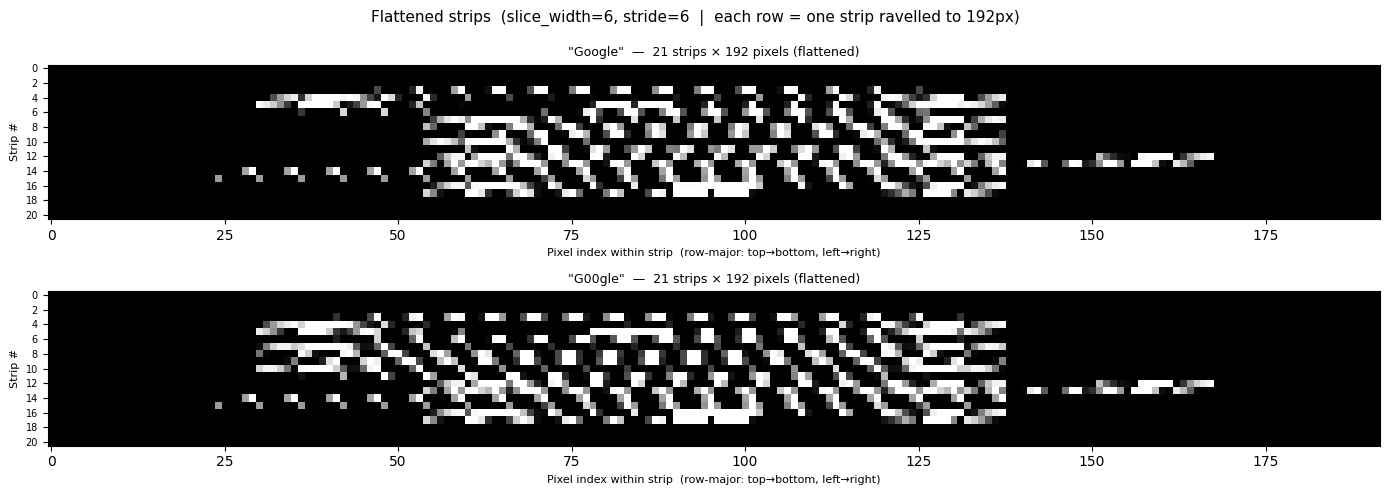

In [10]:
# ── Plot 3: Flattened strips ───────────────────────────────────────────────
# Each strip (h × slice_width) is ravelled to a 1-D vector.
# Displayed as a matrix: rows = strips, columns = pixels.

flat_fig, flat_axes = plt.subplots(2, 1, figsize=(14, 5), squeeze=False)
flat_axes = flat_axes[:, 0]

for ax, w in zip(flat_axes, WORDS):
    strips = slices[w]          # (n, h, sw)
    n, h, sw = strips.shape
    flat = strips.reshape(n, h * sw)   # (n, h*sw)  — each row is one strip
    ax.imshow(flat, cmap='gray', aspect='auto', vmin=0, vmax=1,
              interpolation='nearest')
    ax.set_title(f'"{w}"  —  {n} strips × {h*sw} pixels (flattened)', fontsize=9)
    ax.set_xlabel('Pixel index within strip  (row-major: top→bottom, left→right)', fontsize=8)
    ax.set_ylabel('Strip #', fontsize=8)
    tick_step = max(1, n // 10)
    ticks = list(range(0, n, tick_step))
    ax.set_yticks(ticks)
    ax.set_yticklabels(ticks, fontsize=7)

flat_fig.suptitle(
    f'Flattened strips  '
    f'(slice_width={SLICE_WIDTH}, stride={STRIDE}  |  each row = one strip ravelled to {HEIGHT*SLICE_WIDTH}px)',
    fontsize=11,
)
flat_fig.tight_layout()
plt.show()

# Hyperparameter Sweep — Distribution Analysis
Load every `sweep__*` run, extract best val AUC per run, and visualise how each design axis (pooling, padding, slice width, stride overlap) affects performance.

In [ ]:
%pip install -q pyyaml seaborn


In [6]:
import sys, re
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

ROOT = Path("..").resolve()
RUNS_DIR = ROOT / "outputs" / "runs"

records = []
for run_dir in sorted(RUNS_DIR.glob("sweep__*")):
    cfg_path = run_dir / "config.yaml"
    log_path = run_dir / "log.csv"
    if not cfg_path.exists() or not log_path.exists():
        continue

    with open(cfg_path) as f:
        cfg = yaml.safe_load(f)

    log = pd.read_csv(log_path)
    best_auc = log["val_auc"].max()

    slicing   = cfg.get("slicing",   {})
    model     = cfg.get("model",     {})
    rendering = cfg.get("rendering", {})

    sw = slicing.get("slice_width")
    st = slicing.get("stride")
    records.append({
        "run":            run_dir.name,
        "best_val_auc":   best_auc,
        "pooling":        model.get("pooling", "unknown"),
        "remove_padding": slicing.get("remove_padding", False),
        "background":     rendering.get("background", "unknown"),
        "slice_width":    sw,
        "stride":         st,
        "overlap_type":   "overlapping" if (sw is not None and st is not None and st < sw)
                          else "non-overlapping",
    })

df = pd.DataFrame(records)
df["padding_label"] = df["remove_padding"].map({True: "no padding", False: "with padding"})
df["slice_width"]   = df["slice_width"].astype(int)

print(f"{len(df)} sweep runs loaded")
df.head()


74 sweep runs loaded


,run,best_val_auc,pooling,remove_padding,background,slice_width,stride,overlap_type,padding_label
0,sweep__attention__nopad__black__sw16__st16,0.669655,attention,False,black,16,16,non-overlapping,with padding
1,sweep__attention__nopad__black__sw16__st8,0.700457,attention,False,black,16,8,overlapping,with padding
2,sweep__attention__nopad__black__sw32__st16,0.677615,attention,False,black,32,16,overlapping,with padding
3,sweep__attention__nopad__black__sw32__st32,0.552684,attention,False,black,32,32,non-overlapping,with padding
4,sweep__attention__nopad__black__sw3__st1,0.566229,attention,False,black,3,1,overlapping,with padding


### Helper — violin + strip plot
Each plot shows one hyperparameter axis. The violin gives the density; individual run dots are overlaid so nothing is hidden.

In [7]:
def dist_plot(
    data: pd.DataFrame,
    x: str,
    order: list | None = None,
    title: str = "",
    xlabel: str = "",
    palette: str = "Set2",
    figsize: tuple = (7, 4),
) -> None:
    """Violin + individual-point overlay for one hyperparameter axis."""
    fig, ax = plt.subplots(figsize=figsize)

    if order is None:
        order = sorted(data[x].unique(), key=lambda v: (isinstance(v, str), v))

    sns.violinplot(
        data=data, x=x, y="best_val_auc", order=order,
        palette=palette, inner=None, linewidth=1.2,
        cut=0.5, density_norm="width", ax=ax,
    )
    sns.stripplot(
        data=data, x=x, y="best_val_auc", order=order,
        color="black", alpha=0.45, size=4, jitter=True, ax=ax,
    )

    # Annotate with mean +/- std above each violin
    for i, val in enumerate(order):
        subset = data.loc[data[x] == val, "best_val_auc"]
        ax.text(
            i, subset.max() + 0.005,
            f"n={len(subset)}\n{subset.mean():.3f}\u00b1{subset.std():.3f}",
            ha="center", va="bottom", fontsize=7.5, color="#333",
        )

    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel or x, fontsize=10)
    ax.set_ylabel("Best val AUC", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.grid(axis="y", linewidth=0.5, alpha=0.6)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()


### Pooling strategy

C:\Users\hbori\AppData\Local\Temp\ipykernel_16592\1551007119.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


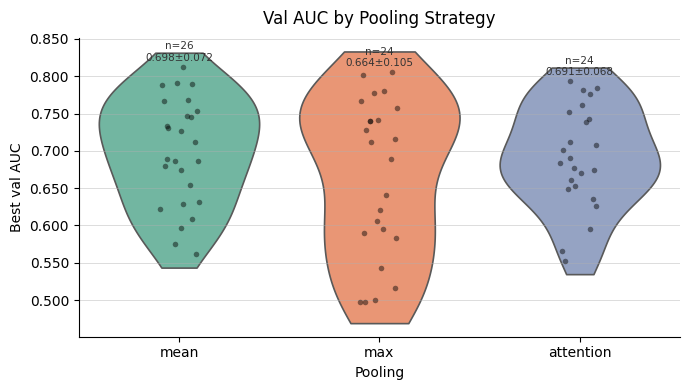

In [8]:
dist_plot(
    df, x="pooling",
    order=["mean", "max", "attention"],
    title="Val AUC by Pooling Strategy",
    xlabel="Pooling",
)


### Padding

C:\Users\hbori\AppData\Local\Temp\ipykernel_16592\1551007119.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


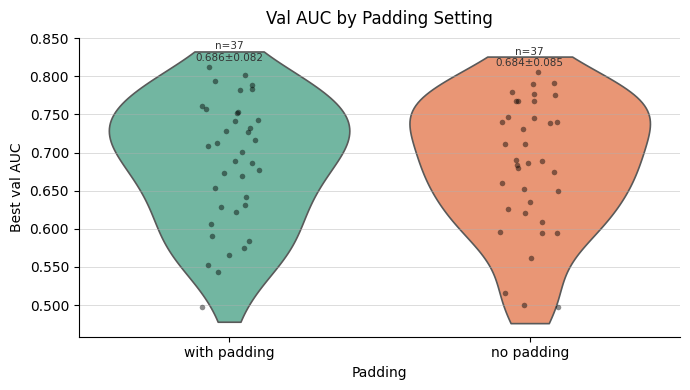

In [9]:
dist_plot(
    df, x="padding_label",
    order=["with padding", "no padding"],
    title="Val AUC by Padding Setting",
    xlabel="Padding",
)


### Slice width
Each violin is one `slice_width` value.

C:\Users\hbori\AppData\Local\Temp\ipykernel_16592\1551007119.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


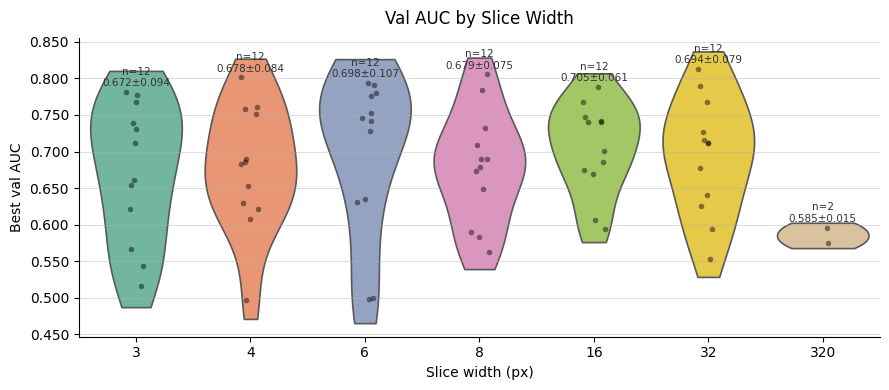

In [10]:
sw_order = sorted(df["slice_width"].unique())
dist_plot(
    df.assign(slice_width=df["slice_width"].astype(str)),
    x="slice_width",
    order=[str(v) for v in sw_order],
    title="Val AUC by Slice Width",
    xlabel="Slice width (px)",
    figsize=(9, 4),
)


### Stride: overlapping vs non-overlapping
`overlapping` = stride < slice_width; `non-overlapping` = stride == slice_width.

C:\Users\hbori\AppData\Local\Temp\ipykernel_16592\1551007119.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


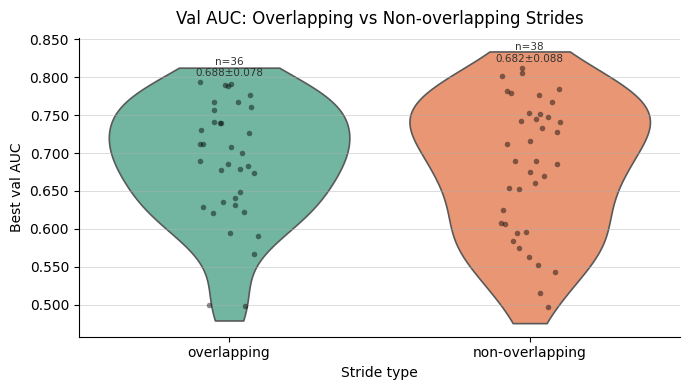

In [11]:
dist_plot(
    df, x="overlap_type",
    order=["overlapping", "non-overlapping"],
    title="Val AUC: Overlapping vs Non-overlapping Strides",
    xlabel="Stride type",
)


### Slice width × stride heatmap (by pooling)
Mean val AUC for each `(slice_width, stride)` combination, one panel per pooling strategy.

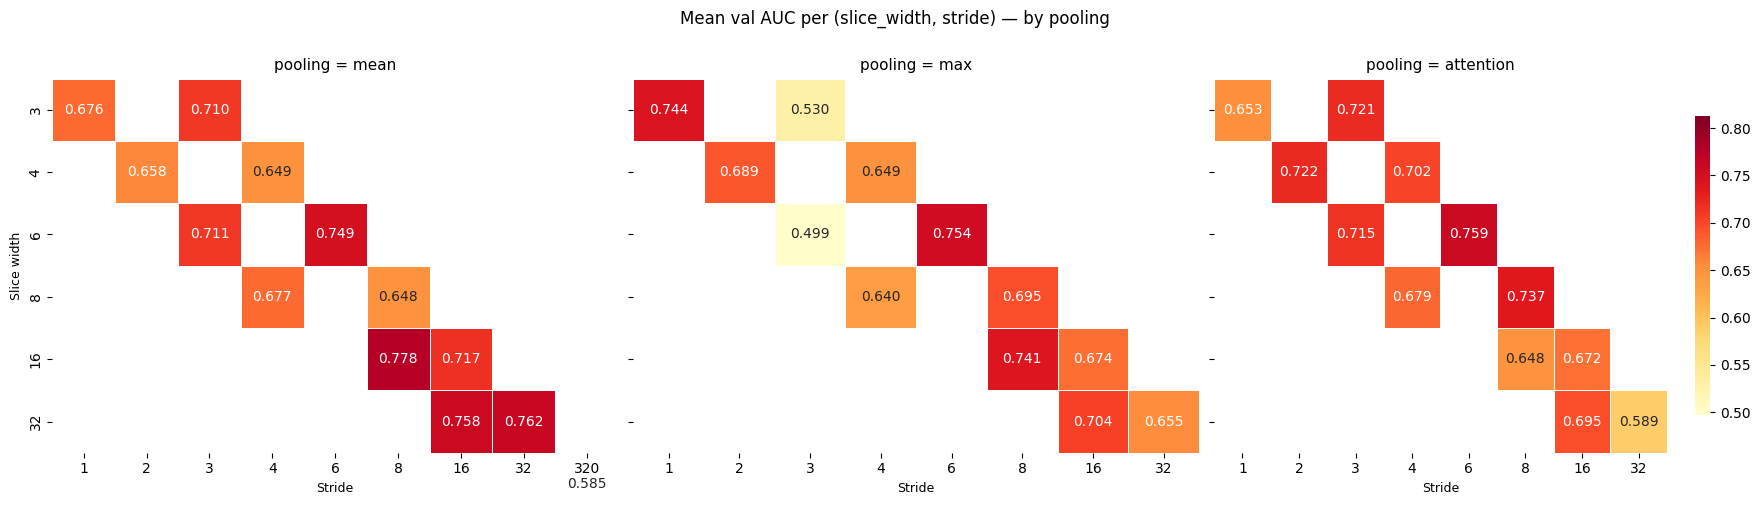

In [12]:
pooling_values = ["mean", "max", "attention"]
fig, axes = plt.subplots(1, len(pooling_values), figsize=(18, 5), sharey=True)

vmin = df["best_val_auc"].min()
vmax = df["best_val_auc"].max()

for ax, pool in zip(axes, pooling_values):
    sub = df[df["pooling"] == pool].copy()
    pivot = sub.pivot_table(
        index="slice_width", columns="stride",
        values="best_val_auc", aggfunc="mean",
    )
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".3f", cmap="YlOrRd",
        vmin=vmin, vmax=vmax, linewidths=0.4,
        cbar=(ax is axes[-1]),
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(f"pooling = {pool}", fontsize=11)
    ax.set_xlabel("Stride", fontsize=9)
    ax.set_ylabel("Slice width" if ax is axes[0] else "", fontsize=9)

plt.suptitle("Mean val AUC per (slice_width, stride) — by pooling", fontsize=12, y=1.00)
plt.tight_layout()
plt.show()


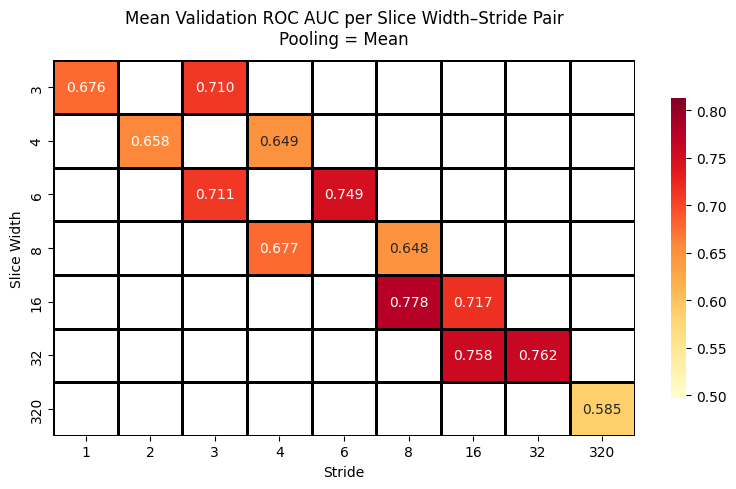

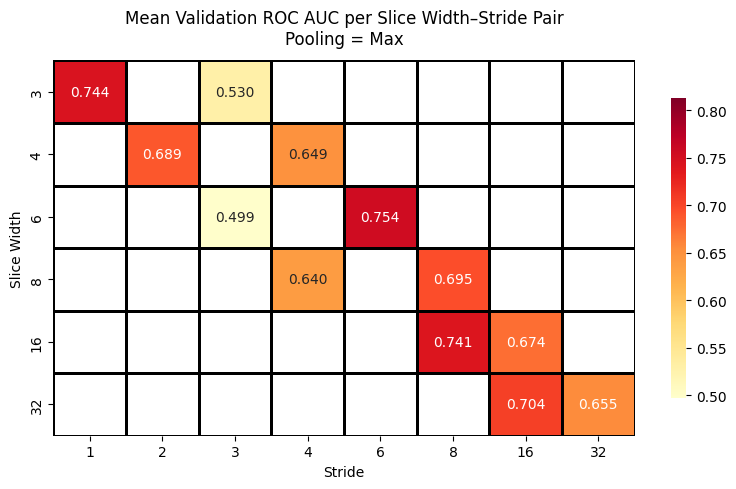

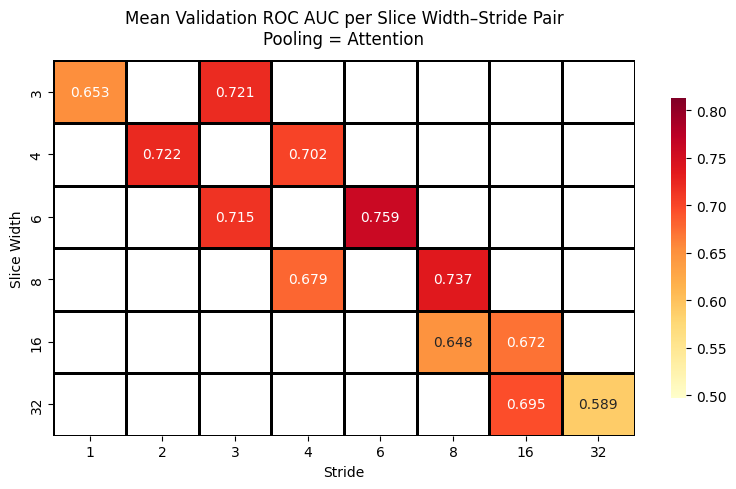

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

pooling_values = ["mean", "max", "attention"]

vmin = df["best_val_auc"].min()
vmax = df["best_val_auc"].max()

for pool in pooling_values:
    sub = df[df["pooling"] == pool].copy()
    pivot = sub.pivot_table(
        index="slice_width",
        columns="stride",
        values="best_val_auc",
        aggfunc="mean",
    )

    plt.figure(figsize=(8, 5))

    ax = sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="YlOrRd",
        vmin=vmin,
        vmax=vmax,
        linewidths=1,
        linecolor="black",
        cbar=True,
        cbar_kws={"shrink": 0.8},
    )

    ax.set_title(
        f"Mean Validation ROC AUC per Slice Width–Stride Pair\nPooling = {pool.capitalize()}",
        fontsize=12,
        pad=12
    )

    ax.set_xlabel("Stride", fontsize=10)
    ax.set_ylabel("Slice Width", fontsize=10)

    # Add major gridlines behind heatmap for easier reading
    ax.set_axisbelow(True)
    ax.grid(True, which="minor", linestyle="-", linewidth=0.5)

    plt.tight_layout()
    plt.show()

### 1d conv training loss

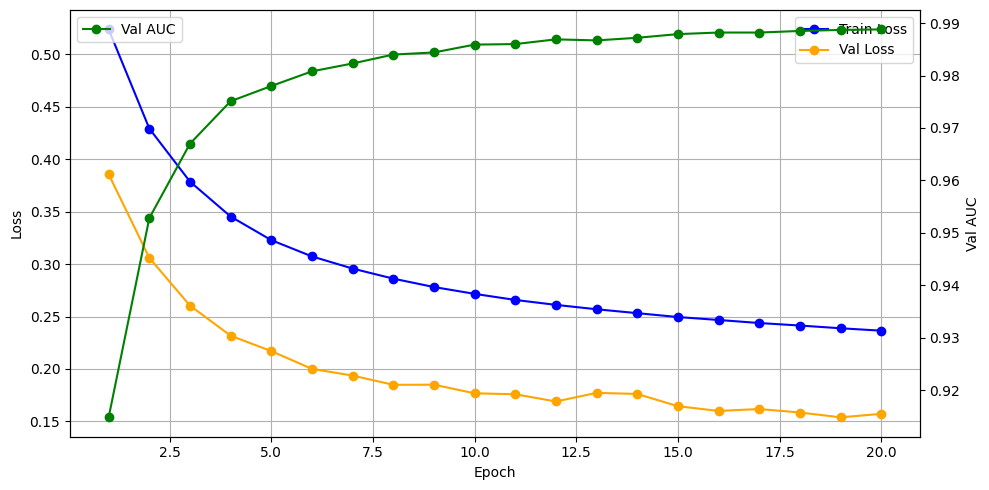

In [4]:
import pandas as pd

training_log = {
    "epoch": list(range(1, 21)),
    "train_loss": [
        0.5237, 0.4292, 0.3786, 0.3453, 0.3228,
        0.3073, 0.2957, 0.2861, 0.2781, 0.2716,
        0.2658, 0.2611, 0.2569, 0.2532, 0.2495,
        0.2467, 0.2438, 0.2414, 0.2388, 0.2365
    ],
    "val_loss": [
        0.3856, 0.3059, 0.2604, 0.2317, 0.2170,
        0.2001, 0.1937, 0.1849, 0.1850, 0.1768,
        0.1759, 0.1690, 0.1772, 0.1762, 0.1645,
        0.1600, 0.1618, 0.1585, 0.1539, 0.1572
    ],
    "val_auc": [
        0.9148, 0.9528, 0.9670, 0.9751, 0.9780,
        0.9808, 0.9823, 0.9840, 0.9844, 0.9859,
        0.9860, 0.9869, 0.9867, 0.9872, 0.9879,
        0.9882, 0.9882, 0.9885, 0.9887, 0.9888
    ],
    "epoch_time_sec": [
        225.7, 230.5, 230.0, 234.6, 230.6,
        230.9, 224.5, 232.3, 234.2, 232.8,
        231.2, 227.7, 230.7, 227.5, 228.3,
        230.9, 239.0, 227.4, 226.4, 225.8
    ]
}

df = pd.DataFrame(training_log)

# Plotting training and validation loss. also plot val_auc on a secondary y-axis.
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df["epoch"], df["train_loss"], label="Train Loss", color="blue", marker="o")
ax1.plot(df["epoch"], df["val_loss"], label="Val Loss", color="orange", marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
ax2 = ax1.twinx()
ax2.plot(df["epoch"], df["val_auc"], label="Val AUC", color="green", marker="o")
ax2.set_ylabel("Val AUC")
ax2.legend(loc="upper left")
ax1.grid(True)
plt.tight_layout()
plt.show()

### BILSTM Training Loss

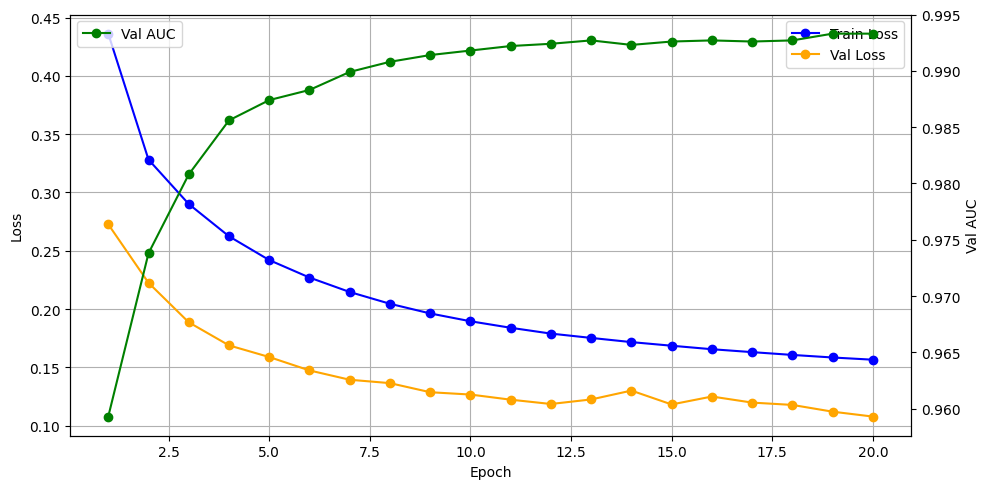

In [1]:
import pandas as pd

training_log = {
    "epoch": list(range(1, 21)),
    "train_loss": [
        0.4363, 0.3282, 0.2901, 0.2624, 0.2420,
        0.2270, 0.2146, 0.2045, 0.1962, 0.1895,
        0.1839, 0.1789, 0.1752, 0.1716, 0.1685,
        0.1655, 0.1630, 0.1606, 0.1584, 0.1565
    ],
    "val_loss": [
        0.2727, 0.2225, 0.1886, 0.1688, 0.1588,
        0.1473, 0.1393, 0.1364, 0.1286, 0.1266,
        0.1222, 0.1185, 0.1224, 0.1300, 0.1181,
        0.1249, 0.1197, 0.1177, 0.1119, 0.1077
    ],
    "val_auc": [
        0.9593, 0.9738, 0.9808, 0.9856, 0.9874,
        0.9883, 0.9899, 0.9908, 0.9914, 0.9918,
        0.9922, 0.9924, 0.9927, 0.9923, 0.9926,
        0.9927, 0.9926, 0.9927, 0.9933, 0.9933
    ],
    "epoch_time_sec": [
        248.6, 247.8, 249.8, 247.7, 253.4,
        249.7, 248.5, 250.9, 250.5, 244.7,
        248.4, 252.0, 249.1, 248.3, 252.1,
        251.4, 248.7, 249.9, 253.2, 249.5
    ]
}

df = pd.DataFrame(training_log)

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df["epoch"], df["train_loss"], label="Train Loss", color="blue", marker="o")
ax1.plot(df["epoch"], df["val_loss"], label="Val Loss", color="orange", marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
ax2 = ax1.twinx()
ax2.plot(df["epoch"], df["val_auc"], label="Val AUC", color="green", marker="o")
ax2.set_ylabel("Val AUC")
ax2.legend(loc="upper left")
ax1.grid(True)
plt.tight_layout()
plt.show()

### Transformer training

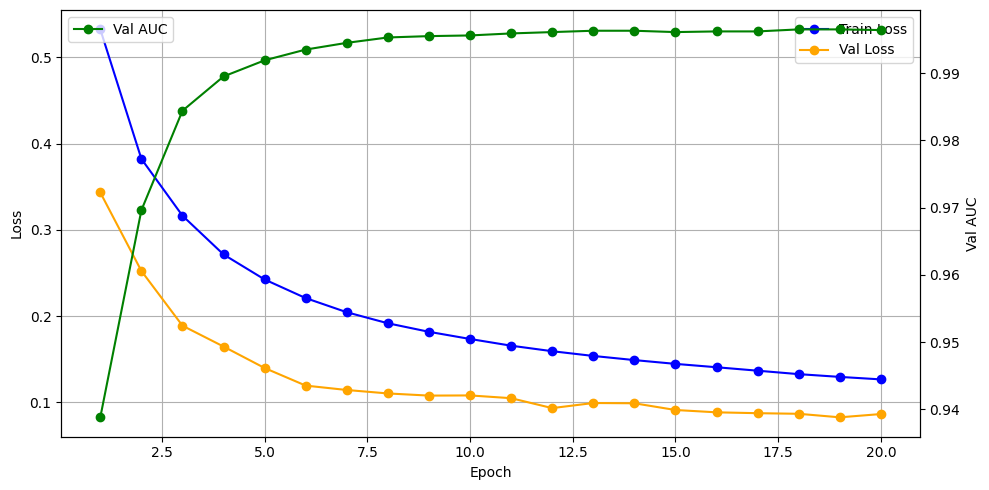

In [2]:
# comparison mean, max and attention pooling strategies trained for 5 epochs.

import pandas as pd

training_log_transformer = {
    "epoch": list(range(1, 21)),
    "train_loss": [
        0.5326, 0.3824, 0.3165, 0.2715, 0.2425,
        0.2209, 0.2045, 0.1917, 0.1818, 0.1735,
        0.1657, 0.1593, 0.1538, 0.1490, 0.1446,
        0.1407, 0.1367, 0.1327, 0.1295, 0.1266
    ],
    "val_loss": [
        0.3434, 0.2524, 0.1889, 0.1647, 0.1398,
        0.1194, 0.1143, 0.1103, 0.1078, 0.1080,
        0.1048, 0.0933, 0.0992, 0.0989, 0.0911,
        0.0884, 0.0874, 0.0867, 0.0826, 0.0864
    ],
    "val_auc": [
        0.9388, 0.9696, 0.9844, 0.9895, 0.9919,
        0.9935, 0.9945, 0.9953, 0.9955, 0.9956,
        0.9959, 0.9961, 0.9963, 0.9963, 0.9961,
        0.9962, 0.9962, 0.9965, 0.9965, 0.9964
    ],
    "epoch_time_sec": [
        251.4, 249.6, 253.1, 250.1, 250.7,
        249.5, 251.5, 250.2, 251.7, 251.9,
        250.5, 248.1, 249.9, 250.1, 249.2,
        250.5, 252.1, 247.9, 249.6, 251.6
    ]
}

df = pd.DataFrame(training_log_transformer)

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df["epoch"], df["train_loss"], label="Train Loss", color="blue", marker="o")
ax1.plot(df["epoch"], df["val_loss"], label="Val Loss", color="orange", marker="o")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
ax2 = ax1.twinx()
ax2.plot(df["epoch"], df["val_auc"], label="Val AUC", color="green", marker="o")
ax2.set_ylabel("Val AUC")
ax2.legend(loc="upper left")
ax1.grid(True)
plt.tight_layout()
plt.show()

### comparing the 4 pooling methods for the transformer training

In [ ]:
import pandas as pd

data = {
    "epoch": [1, 2, 3, 4, 5],
    "attention": [0.8197, 0.8747, 0.9036, 0.8422, 0.8516],
    "mean": [0.8863, 0.9294, 0.9484, 0.9648, 0.9710],
    "max": [0.9388, 0.9696, 0.9844, 0.9895, 0.9919],
    "cls": [0.8309, 0.8493, 0.8547, 0.8548, 0.8571],
}

df = pd.DataFrame(data)

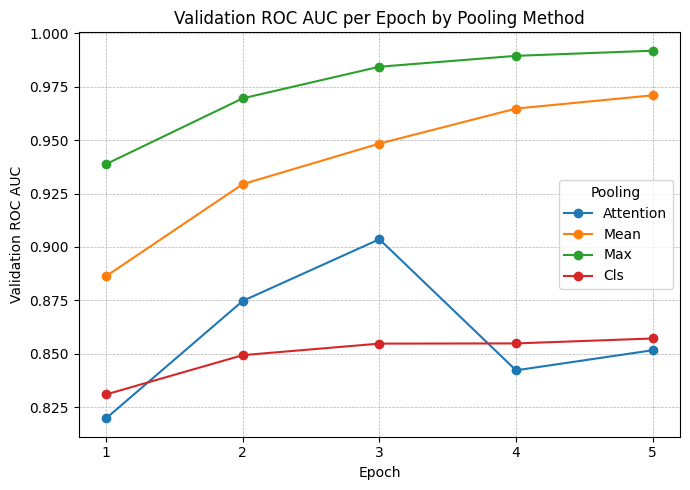

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

for col in ["attention", "mean", "max", "cls"]:
    plt.plot(df["epoch"], df[col], marker="o", label=col.capitalize())

plt.title("Validation ROC AUC per Epoch by Pooling Method")
plt.xlabel("Epoch")
plt.ylabel("Validation ROC AUC")
plt.xticks(df["epoch"])
plt.legend(title="Pooling")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

### confusion matrix for transformer

In [3]:
import pandas as pd

results_transformer_attn = {
    "run": "transformer_attn",
    "roc_auc": 0.9900,
    "avg_precision": 0.9943,

    "best_threshold": 0.4557,
    "best_metrics": {
        "accuracy": 0.9532,
        "precision": 0.9614,
        "recall": 0.9660,
        "f1": 0.9637,
        "specificity": 0.9302,
        "mcc": 0.8980,
    },
    "best_confusion_matrix": {
        "tn": 85342,
        "fp": 6403,
        "fn": 5610,
        "tp": 159531,
    },

    "fixed_threshold": 0.5,
    "fixed_metrics": {
        "accuracy": 0.9531,
        "precision": 0.9653,
        "recall": 0.9616,
        "f1": 0.9635,
        "specificity": 0.9378,
        "mcc": 0.8981,
    },
    "fixed_confusion_matrix": {
        "tn": 86038,
        "fp": 5707,
        "fn": 6334,
        "tp": 158807,
    }
}

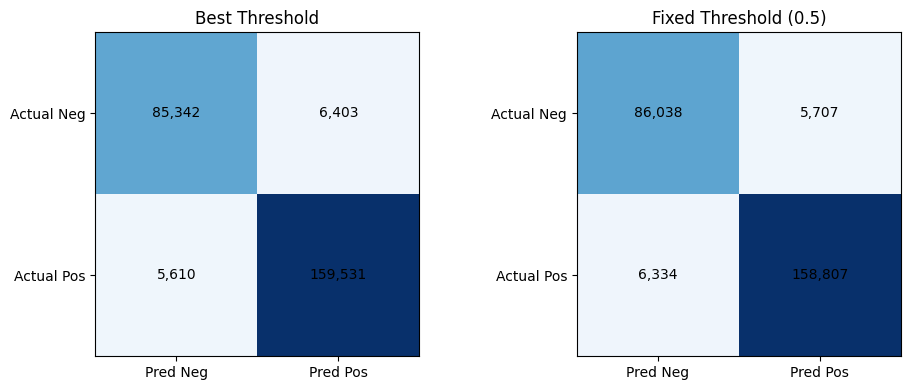

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, key, title in zip(
    axes,
    ["best_confusion_matrix", "fixed_confusion_matrix"],
    ["Best Threshold", "Fixed Threshold (0.5)"]
):
    cm = results_transformer_attn[key]
    matrix = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])

    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=matrix.max())

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i, j]:,}", ha="center", va="center")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Neg", "Pred Pos"])
    ax.set_yticklabels(["Actual Neg", "Actual Pos"])
    ax.set_title(title)

plt.tight_layout()
plt.show()

### confusion matrix for bilstm

In [7]:
results_bilstm = {
    "run": "bilstm",
    "roc_auc": 0.9844,
    "avg_precision": 0.9906,

    "best_threshold": 0.4705,
    "best_metrics": {
        "accuracy": 0.9404,
        "precision": 0.9470,
        "recall": 0.9610,
        "f1": 0.9540,
        "specificity": 0.9032,
        "mcc": 0.8695,
    },
    "best_confusion_matrix": {
        "tn": 82864,
        "fp": 8881,
        "fn": 6440,
        "tp": 158701,
    },

    "fixed_threshold": 0.5,
    "fixed_metrics": {
        "accuracy": 0.9404,
        "precision": 0.9500,
        "recall": 0.9577,
        "f1": 0.9538,
        "specificity": 0.9094,
        "mcc": 0.8699,
    },
    "fixed_confusion_matrix": {
        "tn": 83430,
        "fp": 8315,
        "fn": 6990,
        "tp": 158151,
    }
}

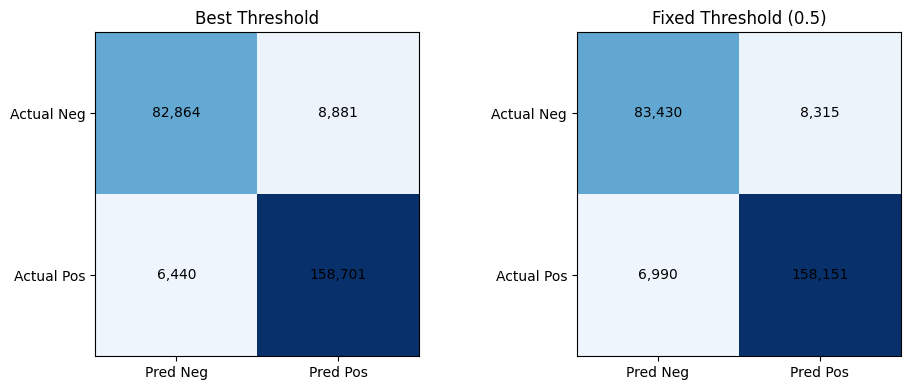

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, key, title in zip(
    axes,
    ["best_confusion_matrix", "fixed_confusion_matrix"],
    ["Best Threshold", "Fixed Threshold (0.5)"]
):
    cm = results_bilstm[key]
    matrix = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])

    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=matrix.max())

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i, j]:,}", ha="center", va="center")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Neg", "Pred Pos"])
    ax.set_yticklabels(["Actual Neg", "Actual Pos"])
    ax.set_title(title)

plt.tight_layout()
plt.show()

### confusion matrix conv1d

In [10]:
results_cnn1d = {
    "run": "cnn_1d",
    "roc_auc": 0.9677,
    "avg_precision": 0.9820,

    "best_threshold": 0.4729,
    "best_metrics": {
        "accuracy": 0.9107,
        "precision": 0.9272,
        "recall": 0.9345,
        "f1": 0.9309,
        "specificity": 0.8679,
        "mcc": 0.8050,
    },
    "best_confusion_matrix": {
        "tn": 79626,
        "fp": 12119,
        "fn": 10810,
        "tp": 154331,
    },

    "fixed_threshold": 0.5,
    "fixed_metrics": {
        "accuracy": 0.9105,
        "precision": 0.9323,
        "recall": 0.9282,
        "f1": 0.9303,
        "specificity": 0.8787,
        "mcc": 0.8055,
    },
    "fixed_confusion_matrix": {
        "tn": 80619,
        "fp": 11126,
        "fn": 11855,
        "tp": 153286,
    }
}

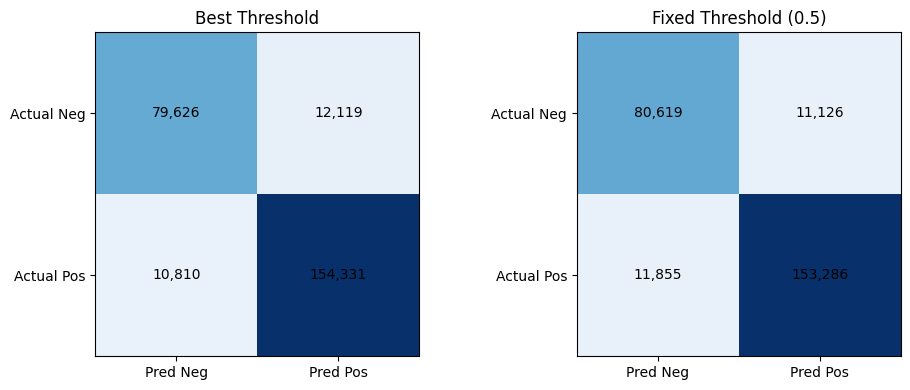

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, key, title in zip(
    axes,
    ["best_confusion_matrix", "fixed_confusion_matrix"],
    ["Best Threshold", "Fixed Threshold (0.5)"]
):
    cm = results_cnn1d[key]
    matrix = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])

    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=matrix.max())

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matrix[i, j]:,}", ha="center", va="center")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Neg", "Pred Pos"])
    ax.set_yticklabels(["Actual Neg", "Actual Pos"])
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 6. Hit-Zone Cross-Attention Heatmap

Runs `'G00gle'` (spoof) and `'Google'` (real) through the full
rendering -> slicing -> `VisualEncoder.encode_slices` -> `HitZoneModule`
pipeline and visualises the cross-attention matrix as a seaborn heatmap.

* **Rows** -- slice indices of the fraudulent name (`'G00gle'`)
* **Columns** -- slice indices of the real name (`'Google'`)
* **Cell value** -- attention weight: how strongly a fraudulent slice
  attends to a given real slice (rows sum to 1)
* **Global score** -- cosine similarity between the cross-attended
  fraudulent representation and the mean real-name embedding

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from rendering.renderer import render_name
from rendering.slicer import slice_image
from models.encoder import VisualEncoder
from models.cross_attention import HitZoneModule

# -- Parameters ---------------------------------------------------------------
REAL_NAME   = 'Google'
SPOOF_NAME  = 'G00gle'
HEIGHT      = 32
SLICE_WIDTH = 4
STRIDE      = 4
EMBED_DIM   = 128
NHEAD       = 4

# -- 1. Render ----------------------------------------------------------------
img_real  = render_name(REAL_NAME,  height=HEIGHT)
img_spoof = render_name(SPOOF_NAME, height=HEIGHT)

# -- 2. Slice -----------------------------------------------------------------
slices_real  = slice_image(img_real,  slice_width=SLICE_WIDTH, stride=STRIDE)
slices_spoof = slice_image(img_spoof, slice_width=SLICE_WIDTH, stride=STRIDE)

N_real, N_spoof = slices_real.shape[0], slices_spoof.shape[0]
print(f'Real  slices : {N_real}  ({REAL_NAME!r})')
print(f'Spoof slices : {N_spoof} ({SPOOF_NAME!r})')

# -- 3. Tensors (add batch dim) -----------------------------------------------
t_real  = torch.tensor(slices_real ).unsqueeze(0)   # (1, N_r, H, SW)
t_spoof = torch.tensor(slices_spoof).unsqueeze(0)   # (1, N_s, H, SW)

# -- 4. Per-slice embeddings via Conv1D stem ----------------------------------
encoder = VisualEncoder(slice_dim=HEIGHT * SLICE_WIDTH, embed_dim=EMBED_DIM)
encoder.eval()
with torch.no_grad():
    emb_real  = encoder.encode_slices(t_real)   # (1, N_r, 128)
    emb_spoof = encoder.encode_slices(t_spoof)  # (1, N_s, 128)

print(f'emb_real  : {tuple(emb_real.shape)}')
print(f'emb_spoof : {tuple(emb_spoof.shape)}')

# -- 5. Cross-attention: spoof queries attend to real keys/values -------------
hit_zone = HitZoneModule(embed_dim=EMBED_DIM, nhead=NHEAD)
hit_zone.eval()
with torch.no_grad():
    score, attn_weights = hit_zone(emb_spoof, emb_real)
    # score        : (1,)
    # attn_weights : (1, N_spoof, N_real)  -- rows sum to 1

attn_matrix = attn_weights[0].numpy()   # (N_spoof, N_real)
print(f'Global cosine similarity : {score.item():.4f}')
print(f'Attention matrix         : {attn_matrix.shape}  '
      f'row-sum mean = {attn_matrix.sum(axis=1).mean():.4f}')

# -- 6. Heatmap ---------------------------------------------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(max(10, N_real * 0.45 + 3), max(7, N_spoof * 0.4 + 3)),
    gridspec_kw={'height_ratios': [1, 3], 'width_ratios': [3, 1]},
)

# top-left: real name rendering (aligns with heatmap x-axis)
axes[0, 0].imshow(img_real, cmap='gray', aspect='auto', vmin=0, vmax=1)
axes[0, 0].set_title(f'Real: {REAL_NAME!r}', fontsize=9)
axes[0, 0].axis('off')

# top-right: empty corner
axes[0, 1].axis('off')

# bottom-left: attention heatmap
ax_heat = axes[1, 0]
sns.heatmap(
    attn_matrix,
    ax=ax_heat,
    cmap='YlOrRd',
    xticklabels=list(range(N_real)),
    yticklabels=list(range(N_spoof)),
    cbar_kws={'label': 'Attention weight'},
    linewidths=0.3,
    linecolor='#ddd',
    vmin=0,
)
ax_heat.set_xlabel(f'Real-name slice index  ("{REAL_NAME}")', fontsize=9)
ax_heat.set_ylabel(f'Spoof-name slice index  ("{SPOOF_NAME}")', fontsize=9)
ax_heat.set_title(
    f'Cross-attention: "{SPOOF_NAME}" (rows) -> "{REAL_NAME}" (cols)\n'
    f'Global cosine similarity: {score.item():.4f}  '
    f'(random weights -- retrain for meaningful attention)',
    fontsize=9,
)

# bottom-right: spoof name rotated to align with heatmap y-axis
axes[1, 1].imshow(img_spoof.T, cmap='gray', aspect='auto', vmin=0, vmax=1)
axes[1, 1].set_title(
    f'Spoof: {SPOOF_NAME!r}', fontsize=9,
    rotation=270, x=1.18, y=0.5, va='center',
)
axes[1, 1].axis('off')

plt.suptitle(
    f'HitZoneModule  --  cross-attention heatmap\n'
    f'Rows = fraudulent slices ("{SPOOF_NAME}"), '
    f'Cols = real slices ("{REAL_NAME}")',
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

OSError: [WinError 126] The specified module could not be found. Error loading "c:\Users\hbori\OneDrive\Documents\MIT env\.venv\Lib\site-packages\torch\lib\fbgemm.dll" or one of its dependencies.